In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv("../data/final_dataset.csv")

df.head()

,replica_id,algo,depth,run_id,handshake_ms,timestamp,cert_bytes,session_resumption
0,1,rsa2048,1,1,1.024625,2026-04-27T17:27:06,1127,OFF
1,1,rsa2048,1,2,0.952375,2026-04-27T17:27:06,1127,OFF
2,1,rsa2048,1,3,0.948500,2026-04-27T17:27:06,1127,OFF
3,1,rsa2048,1,4,0.942417,2026-04-27T17:27:06,1127,OFF
4,1,rsa2048,1,5,0.941666,2026-04-27T17:27:06,1127,OFF


# Week 6 Statistical Analysis

This notebook summarizes the statistical analysis of the TLS handshake benchmark dataset.

In [3]:
# Summary Statistics 
summary = (
    df.groupby(["algo", "depth"])["handshake_ms"]
    .agg(
        mean="mean",
        median="median",
        std="std",
        p95=lambda x: x.quantile(0.95),
        p99=lambda x: x.quantile(0.99),
        count="count"
    )
    .reset_index()
)

summary["cv"] = summary["std"] / summary["mean"]
summary.round(4)

,algo,depth,mean,median,std,p95,p99,count,cv
0,ec256,1,0.4389,0.4207,0.0660,0.5480,0.6950,650,0.1505
1,ec256,2,0.4995,0.4826,0.0517,0.5971,0.7527,650,0.1036
2,ec256,3,0.5397,0.5293,0.0510,0.6374,0.7846,650,0.0944
3,ec256,4,0.5940,0.5775,0.0607,0.7086,0.8733,650,0.1022
4,ec384,1,0.9202,0.8558,0.2268,1.1330,2.2461,650,0.2465
5,ec384,2,1.0664,1.0497,0.1230,1.1511,1.2720,650,0.1153
6,ec384,3,1.3063,1.2765,0.1172,1.4648,1.8314,650,0.0897
7,ec384,4,1.5229,1.5082,0.0965,1.6202,1.7803,650,0.0634
8,rsa2048,1,0.6940,0.6756,0.0658,0.8311,0.9505,650,0.0948
9,rsa2048,2,0.7344,0.7127,0.0595,0.8656,0.9938,650,0.0810


In [4]:
# Normality Test
from scipy.stats import shapiro

normality_results = []

for (algo, depth), group in df.groupby(["algo", "depth"]):
    sample = group["handshake_ms"].sample(500, random_state=42)
    stat, pvalue = shapiro(sample)

    normality_results.append({
        "algo": algo,
        "depth": depth,
        "shapiro_stat": stat,
        "pvalue": pvalue,
        "normal_distribution": pvalue > 0.05
    })

normality_df = pd.DataFrame(normality_results)
normality_df

,algo,depth,shapiro_stat,pvalue,normal_distribution
0,ec256,1,0.606026,3.653586e-32,False
1,ec256,2,0.552327,9.207646e-34,False
2,ec256,3,0.676119,8.603096e-30,False
3,ec256,4,0.614327,6.686307e-32,False
4,ec384,1,0.433855,8.331113e-37,False
5,ec384,2,0.683053,1.551605e-29,False
6,ec384,3,0.483849,1.366213e-35,False
7,ec384,4,0.368339,2.846242e-38,False
8,rsa2048,1,0.656474,1.704982e-30,False
9,rsa2048,2,0.626468,1.649222e-31,False


In [5]:
# Mann-Whitney U Test
from scipy.stats import mannwhitneyu

comparisons = [
    ("ec256", "rsa2048"),
    ("ec384", "rsa4096"),
    ("ec256", "ec384"),
    ("rsa2048", "rsa4096")
]

mw_results = []

for a1, a2 in comparisons:
    g1 = df[df["algo"] == a1]["handshake_ms"]
    g2 = df[df["algo"] == a2]["handshake_ms"]

    stat, pvalue = mannwhitneyu(g1, g2, alternative="two-sided")

    mw_results.append({
        "algo_1": a1,
        "algo_2": a2,
        "u_statistic": stat,
        "pvalue": pvalue,
        "significant": pvalue < 0.05
    })

mw_df = pd.DataFrame(mw_results)
mw_df

,algo_1,algo_2,u_statistic,pvalue,significant
0,ec256,rsa2048,152725.5,0.0,True
1,ec384,rsa4096,7470.0,0.0,True
2,ec256,ec384,9399.0,0.0,True
3,rsa2048,rsa4096,0.0,0.0,True


In [6]:
# Regression Analysis
import statsmodels.formula.api as smf

model = smf.ols(
    formula="handshake_ms ~ C(algo) + depth",
    data=df
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           handshake_ms   R-squared:                       0.915
Model:                            OLS   Adj. R-squared:                  0.915
Method:                 Least Squares   F-statistic:                 2.798e+04
Date:                Sat, 16 May 2026   Prob (F-statistic):               0.00
Time:                        17:21:39   Log-Likelihood:                -117.73
No. Observations:               10400   AIC:                             245.5
Df Residuals:                   10395   BIC:                             281.7
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.3206      0

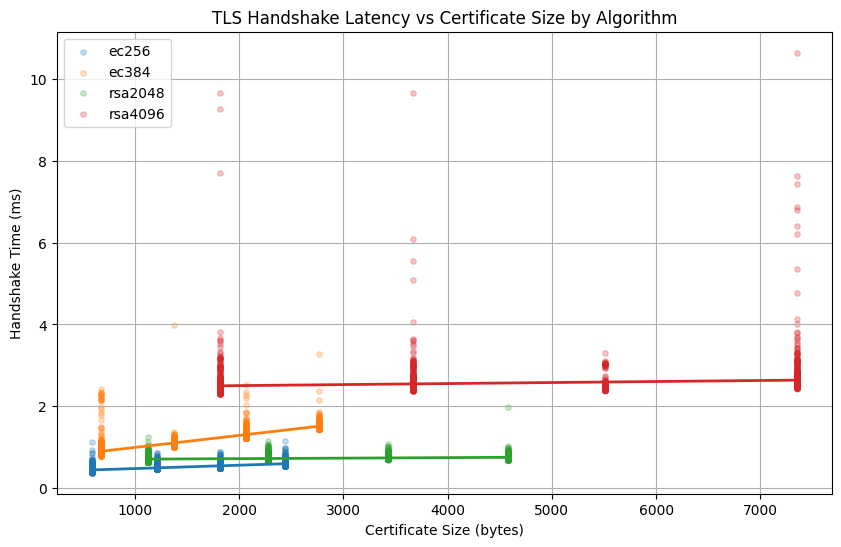

In [7]:
# Scatter Plot
algorithms = ["ec256", "ec384", "rsa2048", "rsa4096"]

plt.figure(figsize=(10, 6))

for algo in algorithms:
    subset = df[df["algo"] == algo]

    plt.scatter(
        subset["cert_bytes"],
        subset["handshake_ms"],
        alpha=0.25,
        s=15,
        label=algo
    )

    z = np.polyfit(subset["cert_bytes"], subset["handshake_ms"], 1)
    p = np.poly1d(z)

    x_sorted = np.sort(subset["cert_bytes"].unique())

    plt.plot(
        x_sorted,
        p(x_sorted),
        linewidth=2
    )

plt.xlabel("Certificate Size (bytes)")
plt.ylabel("Handshake Time (ms)")
plt.title("TLS Handshake Latency vs Certificate Size by Algorithm")
plt.legend()
plt.grid(True)
plt.show()